# 07 — Финальная витрина рекомендаций

## Цель ноутбука

Это финальный шаг всего аналитического модуля.  
Мы собираем **итоговую таблицу рекомендаций** — готовый продукт для маркетинговой команды.

## Что мы делаем?

Для каждой даты прогнозируемого недозаселения формируем строку:
- Какая загрузка ожидается?
- Насколько это хуже цели?
- Какой сегмент нацеливать в первую очередь?
- Почему именно этот сегмент?
- Что конкретно делать (suggested_action)?

## Итоговая таблица

```
date | forecast_load | target_load | load_gap | season
     | top_segment_id | top_segment_name | top_3_segment_ids
     | score_top | recommendation_reason | suggested_action
```

## Входные данные
- `ml/forecasting/artifacts_forecasting/underload_dates.parquet`
- `artifacts_recommender/segment_scores.parquet`
- `artifacts_recommender/segment_history.parquet`

## Выходные артефакты
- `artifacts_recommender/recommendations.parquet` — машинный формат
- `artifacts_recommender/recommendations.csv` — для Excel/маркетинга

## 1. Импорты и загрузка

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

warnings.filterwarnings('ignore')

FORECAST_DIR = Path('..') / 'forecasting' / 'artifacts_forecasting'
OUT_DIR      = Path('artifacts_recommender')

df_underload = pd.read_parquet(FORECAST_DIR / 'underload_dates.parquet')
df_underload['ds'] = pd.to_datetime(df_underload['ds'])

df_scores    = pd.read_parquet(OUT_DIR / 'segment_scores.parquet')
df_scores['ds'] = pd.to_datetime(df_scores['ds'])

df_seg_hist  = pd.read_parquet(OUT_DIR / 'segment_history.parquet')

SEGMENT_NAMES = {
    0: 'Summer Family ULTRA',
    1: 'Weekend Getaway',
    2: 'Weekday Adults',
    3: 'Last-minute Winter',
    4: 'Young Spring Groups',
    5: 'Medical Treatment'
}

print(f'Проблемных дат: {len(df_underload):,}')
print(f'Строк в матрице скоров: {len(df_scores):,}')

C:\Users\sp1ts\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Проблемных дат: 160
Строк в матрице скоров: 960


## 2. Шаблоны причин и действий

Для каждого сегмента задаём текстовые шаблоны, которые объясняют **почему** выбран именно этот сегмент.  
Это делает рекомендации понятными для маркетолога без знания ML.

Дополнительно задаём `suggested_action` — конкретную рекомендацию по каналу и типу акции.

In [2]:
# Базовые описания сегментов для текстовых причин
SEGMENT_REASONS = {
    0: (
        "Семейный сегмент ULTRA (C0): пик активности — лето, "
        "средняя длительность 7+ ночей, высокий ценовой tier. "
        "Мотивирует семейный летний отдых с детьми."
    ),
    1: (
        "Выходной сегмент Weekend Getaway (C1): 99%+ заездов в пятницу-субботу, "
        "средняя длительность 4 ночи. Хорошо реагирует на предложения "
        "выходного тура в пятницу."
    ),
    2: (
        "Сегмент 'Weekday Adults' (C2): взрослые гости без детей, "
        "заезды в будние дни, длительность 8+ ночей. "
        "Целевой для программ недельного оздоровления."
    ),
    3: (
        "Last-minute Winter (C3): лояльный сегмент с высоким prev_stays, "
        "бронирует за 1 неделю до заезда, пик — зима и весна. "
        "Реагирует на срочные 'горящие' предложения."
    ),
    4: (
        "Young Spring Groups (C4): молодая аудитория 22 года, "
        "групповые туры, пик — весна. LIGHT ценовой tier. "
        "Целевой для корпоративных и групповых предложений."
    ),
    5: (
        "Medical Treatment (C5): гости с лечебной мотивацией, "
        "самая длинная длительность (10+ ночей), высокий ценовой tier. "
        "Целевой для медицинских и оздоровительных программ."
    ),
}

# Рекомендуемые действия по сезонам и сегментам
SEGMENT_ACTIONS = {
    (0, 'summer'): 'Email-рассылка семьям: летний тур с детьми, скидка на 3-й день проживания',
    (0, 'spring'): 'Таргетинг в соцсетях: бронирование летнего тура заранее со скидкой',
    (0, 'winter'): 'Ретаргетинг: «Забронируй летний отпуск сейчас»',
    (0, 'autumn'): 'Ретаргетинг: «Забронируй летний отпуск со скидкой»',
    (1, 'summer'): 'Push-уведомления в пятницу: скидка на выходной тур в эти выходные',
    (1, 'winter'): 'Email: новогодний мини-тур с пятницы по воскресенье',
    (1, 'spring'): 'SMS в четверг-пятницу: «Выходные в санатории — бронируй сейчас»',
    (1, 'autumn'): 'Email: осенний уикенд-тур, специальная цена на 2 ночи',
    (2, 'summer'): 'Email B2C: недельная оздоровительная программа, без выходных',
    (2, 'winter'): 'Email: зимняя неделя оздоровления, спецпредложение для 40+',
    (2, 'spring'): 'Таргетинг 35-55 лет: весенний курс оздоровления на 7-10 ночей',
    (2, 'autumn'): 'Email: «Осенний детокс» — программа для взрослых на неделю',
    (3, 'winter'): 'SMS «горящее»: скидка 15%, заезд в течение 7 дней',
    (3, 'spring'): 'SMS «горящее»: весенние «окна», заезд на 3 ночи',
    (3, 'summer'): 'Push «горящее»: летнее место освободилось, 10% скидка',
    (3, 'autumn'): 'SMS «горящее»: осенние выходные, 2 ночи по спеццене',
    (4, 'spring'): 'B2B-рассылка корпоративным клиентам: групповой весенний тур',
    (4, 'summer'): 'Таргетинг 18-25 лет в ВК/Telegram: летний групповой тур',
    (4, 'winter'): 'Корпоративное предложение: новогодний корпоратив, группы от 10',
    (4, 'autumn'): 'B2B: осенний корпоратив-тимбилдинг, спецпредложение для групп',
    (5, 'summer'): 'Email врачам-партнёрам: направление пациентов на летний курс',
    (5, 'winter'): 'Email ДМС-партнёрам: зимний санаторно-курортный курс',
    (5, 'spring'): 'Таргетинг по ключевым словам: санаторное лечение весной',
    (5, 'autumn'): 'Email медицинским партнёрам: осенний оздоровительный курс',
}

def get_action(cluster_id: int, season: str) -> str:
    """Возвращает рекомендацию по действию для сегмента и сезона."""
    return SEGMENT_ACTIONS.get((cluster_id, season),
                                f'Таргетинг сегмента C{cluster_id} на период {season}')

print('Шаблоны причин и действий настроены.')
print(f'Покрыто комбинаций (сегмент, сезон): {len(SEGMENT_ACTIONS)}')

Шаблоны причин и действий настроены.
Покрыто комбинаций (сегмент, сезон): 24


## 3. Сборка финальной витрины

Для каждой даты:
1. Берём топ-1 и топ-3 сегмента по score
2. Формируем текстовые поля `recommendation_reason` и `suggested_action`
3. Объединяем с данными о прогнозе (загрузка, дефицит)

In [3]:
print('Собираем финальную витрину рекомендаций...')

recommendations = []

for ds_val, group in df_scores.groupby('ds'):
    # Сортируем по убыванию score → топ-1 первый
    group_sorted = group.sort_values('score', ascending=False).reset_index(drop=True)

    # Топ-1 сегмент
    top1 = group_sorted.iloc[0]

    # Топ-3 сегментов (IDs через запятую)
    top3_ids  = group_sorted.head(3)['cluster_v4'].tolist()
    top3_names = [SEGMENT_NAMES[cid] for cid in top3_ids]

    season = top1['season']

    # Получаем контекст даты из таблицы underload
    date_ctx = df_underload[df_underload['ds'] == ds_val].iloc[0]

    recommendations.append({
        # Дата
        'date':                ds_val,
        'season':              season,

        # Прогноз загрузки
        'forecast_load':       round(top1['yhat'], 1),
        'forecast_lower':      round(float(date_ctx.get('yhat_lower', top1['yhat'] * 0.85)), 1),
        'forecast_upper':      round(float(date_ctx.get('yhat_upper', top1['yhat'] * 1.15)), 1),
        'target_load':         round(float(date_ctx.get('target_load_global', 0)), 1),
        'load_gap':            round(top1['load_gap'], 1),
        'underload_pct':       top1['underload_pct'],

        # Рекомендации
        'top_segment_id':      int(top1['cluster_v4']),
        'top_segment_name':    SEGMENT_NAMES[int(top1['cluster_v4'])],
        'top_3_segment_ids':   str(top3_ids),       # '[0, 5, 2]'
        'top_3_segment_names': ', '.join(top3_names),
        'score_top':           top1['score'],

        # Компоненты скора топ-1 для объяснимости
        'score_season':        top1['score_season'],
        'score_value':         top1['score_value'],
        'score_stability':     top1['score_stability'],
        'score_lead':          top1['score_lead'],

        # Текстовые объяснения
        'recommendation_reason': SEGMENT_REASONS[int(top1['cluster_v4'])],
        'suggested_action':      get_action(int(top1['cluster_v4']), season),
    })

df_recs = pd.DataFrame(recommendations)
df_recs['date'] = pd.to_datetime(df_recs['date'])
df_recs = df_recs.sort_values('date').reset_index(drop=True)

print(f'Строк в витрине рекомендаций: {len(df_recs):,}')
print(f'\nПервые строки:')
df_recs[['date','season','forecast_load','target_load','load_gap','top_segment_name','score_top']].head(10)

Собираем финальную витрину рекомендаций...


Строк в витрине рекомендаций: 160

Первые строки:


,date,season,forecast_load,target_load,load_gap,top_segment_name,score_top
0,2025-10-31,autumn,293.2,349.0,252.6,Medical Treatment,0.9147
1,2025-11-01,autumn,291.1,349.0,254.7,Medical Treatment,0.9147
2,2025-11-02,autumn,280.2,349.0,265.6,Medical Treatment,0.9147
3,2025-11-03,autumn,296.9,349.0,248.9,Medical Treatment,0.9147
4,2025-11-04,autumn,338.4,349.0,207.4,Medical Treatment,0.9147
5,2025-11-05,autumn,324.0,349.0,221.8,Medical Treatment,0.9147
6,2025-11-06,autumn,329.1,349.0,216.7,Medical Treatment,0.9147
7,2025-11-07,autumn,339.7,349.0,206.1,Medical Treatment,0.9147
8,2025-11-08,autumn,342.8,349.0,203.0,Medical Treatment,0.9147
9,2025-11-09,autumn,324.6,349.0,221.2,Medical Treatment,0.9147


## 4. Финальная проверка качества витрины

In [4]:
print('=== ПРОВЕРКА КАЧЕСТВА ВИТРИНЫ ===')

# 1. Нет пустых recommendation_reason
empty_reasons = df_recs['recommendation_reason'].isna().sum()
print(f'[{"OK" if empty_reasons == 0 else "FAIL"}] Пустых recommendation_reason: {empty_reasons}')

# 2. Все score в диапазоне [0, 1]
valid_scores = ((df_recs['score_top'] >= 0) & (df_recs['score_top'] <= 1)).all()
print(f'[{"OK" if valid_scores else "FAIL"}] Score в диапазоне [0,1]: {valid_scores}')

# 3. В top-1 должны встречаться разные сегменты, но не обязательно все 6:
# если недозагрузка есть только в части сезонов, часть сегментов закономерно не попадёт в top-1.
unique_segs = df_recs['top_segment_id'].nunique()
expected_min_segments = min(df_recs['season'].nunique(), 6)
print(f'[{"OK" if unique_segs >= expected_min_segments else "WARN"}] Уникальных сегментов в топ-1: {unique_segs}/6')

# 4. Проверка бизнес-логики: зимой лидирует C3
winter_top = df_recs[df_recs['season'] == 'winter']['top_segment_id'].mode()
expected_winter = 3
is_c3_winter_top = expected_winter in winter_top.values if len(winter_top) > 0 else False
print(f'[{"OK" if is_c3_winter_top else "CHECK"}] Зимой лидирует C3 (Last-minute Winter): {is_c3_winter_top}')

# 5. Проверка: летом лидирует C0 или C5, если летние даты вообще есть в витрине
summer_top = df_recs[df_recs['season'] == 'summer']['top_segment_id'].mode()
expected_summer = [0, 5]
if len(summer_top) == 0:
    print('[SKIP] Летних дат недозаселения нет, летняя проверка не применяется')
else:
    is_summer_ok = any(s in summer_top.values for s in expected_summer)
    print(f'[{"OK" if is_summer_ok else "CHECK"}] Летом лидирует C0 или C5: {is_summer_ok}')

print('\nРаспределение рекомендаций по сегментам:')
top_dist = df_recs['top_segment_id'].value_counts().sort_index()
for cid, cnt in top_dist.items():
    print(f'  C{cid} {SEGMENT_NAMES[cid]:25s}: {cnt} дней')

=== ПРОВЕРКА КАЧЕСТВА ВИТРИНЫ ===
[OK] Пустых recommendation_reason: 0
[OK] Score в диапазоне [0,1]: True
[OK] Уникальных сегментов в топ-1: 4/6
[OK] Зимой лидирует C3 (Last-minute Winter): True
[OK] Летом лидирует C0 или C5: True

Распределение рекомендаций по сегментам:
  C0 Summer Family ULTRA      : 4 дней
  C3 Last-minute Winter       : 80 дней
  C4 Young Spring Groups      : 29 дней
  C5 Medical Treatment        : 47 дней


## 5. Визуализация витрины рекомендаций

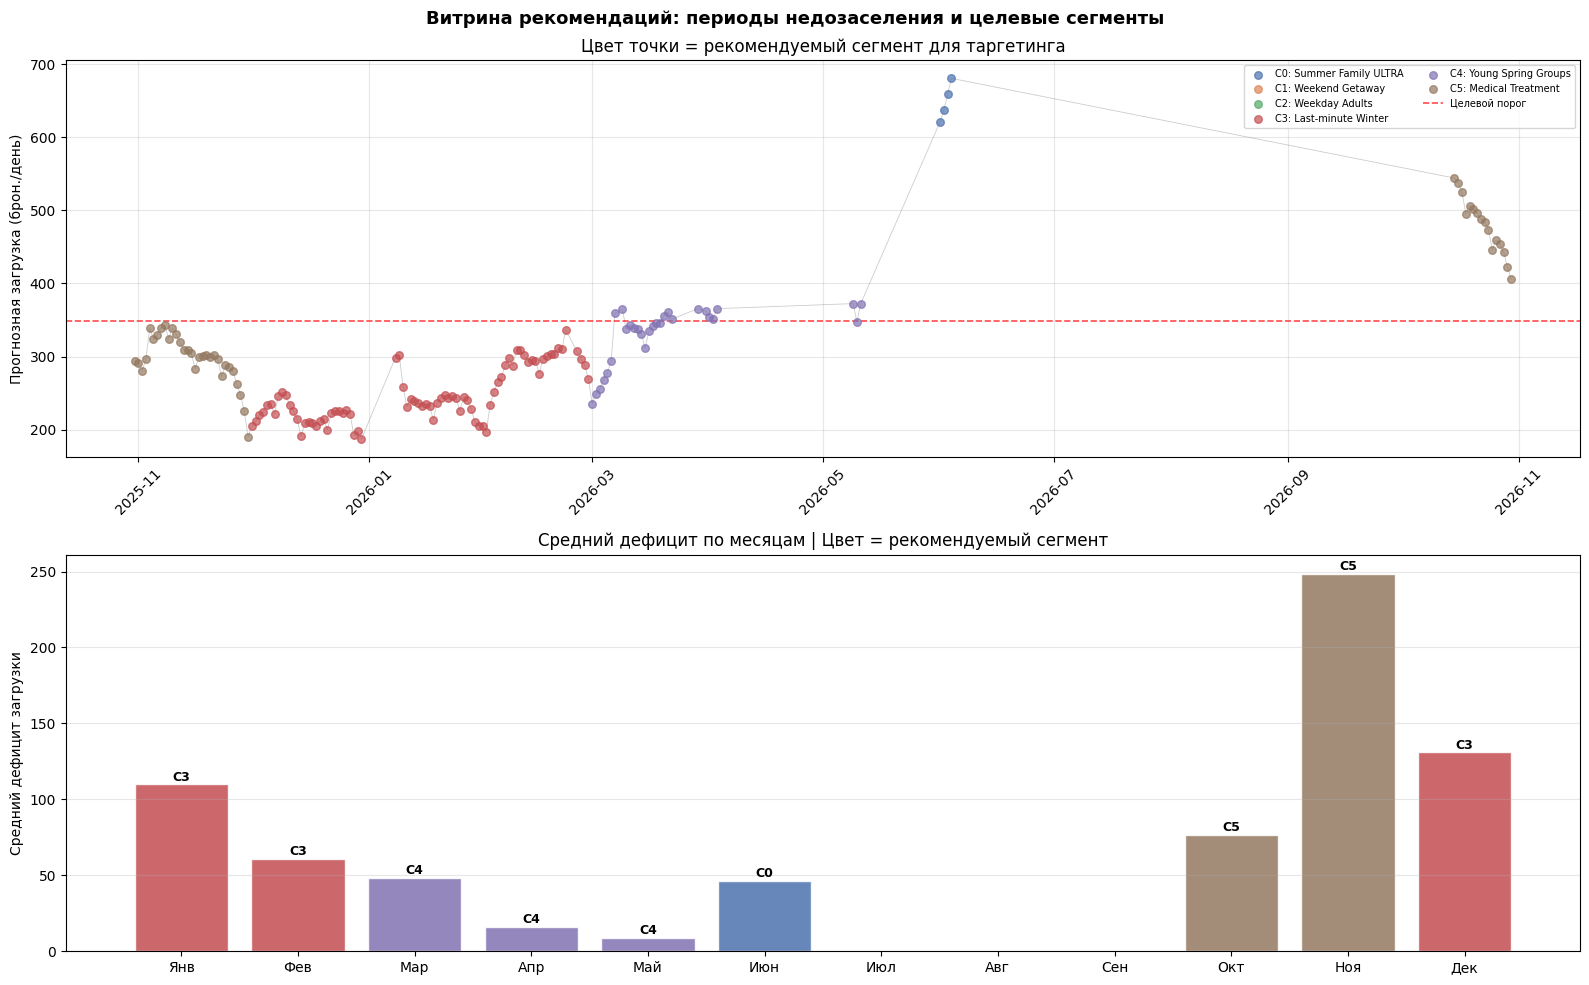

График сохранён: artifacts_recommender/recommendations_overview.png


In [5]:
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Витрина рекомендаций: периоды недозаселения и целевые сегменты', fontsize=13, fontweight='bold')

# ── График 1: Загрузка + цветовая маркировка по рекомендуемому сегменту ──────
ax1 = axes[0]

for cid in range(6):
    seg_mask = df_recs['top_segment_id'] == cid
    seg_dates = df_recs[seg_mask]
    ax1.scatter(seg_dates['date'], seg_dates['forecast_load'],
                color=COLORS[cid], label=f'C{cid}: {SEGMENT_NAMES[cid]}',
                s=30, alpha=0.7, zorder=5)

# Добавляем линию прогноза
ax1.plot(df_recs['date'], df_recs['forecast_load'], color='gray', linewidth=0.6, alpha=0.4)

# Целевой порог
if 'target_load' in df_recs.columns:
    ax1.axhline(y=df_recs['target_load'].iloc[0], color='red', linestyle='--',
                linewidth=1.2, label=f'Целевой порог', alpha=0.7)

ax1.set_ylabel('Прогнозная загрузка (брон./день)')
ax1.set_title('Цвет точки = рекомендуемый сегмент для таргетинга')
ax1.legend(loc='upper right', fontsize=7, ncol=2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,3,5,7,9,11]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.grid(True, alpha=0.3)

# ── График 2: Ежемесячный дефицит и рекомендуемые сегменты ──────────────────
ax2 = axes[1]
df_recs['month'] = df_recs['date'].dt.month
monthly_gap = df_recs.groupby('month')['load_gap'].mean()
monthly_top_seg = df_recs.groupby('month')['top_segment_id'].agg(lambda x: x.mode()[0])

bar_colors = [COLORS[int(monthly_top_seg.get(m, 0))] for m in monthly_gap.index]
bars = ax2.bar(monthly_gap.index, monthly_gap.values, color=bar_colors, alpha=0.85, edgecolor='white')

month_names = ['','Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names[1:])
ax2.set_ylabel('Средний дефицит загрузки')
ax2.set_title('Средний дефицит по месяцам | Цвет = рекомендуемый сегмент')
ax2.grid(True, alpha=0.3, axis='y')

for bar, (month, seg_id) in zip(bars, monthly_top_seg.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'C{int(seg_id)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'recommendations_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: artifacts_recommender/recommendations_overview.png')

## 6. Пример рекомендаций для маркетинга

In [6]:
# Показываем топ-10 «самых проблемных» дат
print('=== ТОП-10 ДАТ С НАИБОЛЬШИМ ДЕФИЦИТОМ ===')
print('(Рекомендации для маркетинга)\n')

top10 = df_recs.sort_values('load_gap', ascending=False).head(10)

for _, row in top10.iterrows():
    print(f"{'─'*60}")
    print(f"Дата:        {row['date'].date()}  ({row['season']})")
    print(f"Прогноз:     {row['forecast_load']:.0f} брон./день  (цель: {row['target_load']:.0f}, дефицит: {row['load_gap']:.0f})")
    print(f"Сегмент №1:  C{row['top_segment_id']} — {row['top_segment_name']}  (score: {row['score_top']:.3f})")
    print(f"Топ-3:       {row['top_3_segment_names']}")
    print(f"Причина:     {row['recommendation_reason'][:120]}...")
    print(f"Действие:    {row['suggested_action']}")

print(f"{'─'*60}")

=== ТОП-10 ДАТ С НАИБОЛЬШИМ ДЕФИЦИТОМ ===
(Рекомендации для маркетинга)

────────────────────────────────────────────────────────────
Дата:        2025-11-30  (autumn)
Прогноз:     190 брон./день  (цель: 349, дефицит: 355)
Сегмент №1:  C5 — Medical Treatment  (score: 0.915)
Топ-3:       Medical Treatment, Weekday Adults, Weekend Getaway
Причина:     Medical Treatment (C5): гости с лечебной мотивацией, самая длинная длительность (10+ ночей), высокий ценовой tier. Целев...
Действие:    Email медицинским партнёрам: осенний оздоровительный курс
────────────────────────────────────────────────────────────
Дата:        2025-11-29  (autumn)
Прогноз:     225 брон./день  (цель: 349, дефицит: 321)
Сегмент №1:  C5 — Medical Treatment  (score: 0.915)
Топ-3:       Medical Treatment, Weekday Adults, Weekend Getaway
Причина:     Medical Treatment (C5): гости с лечебной мотивацией, самая длинная длительность (10+ ночей), высокий ценовой tier. Целев...
Действие:    Email медицинским партнёрам: осенний 

## 7. Сохранение финального артефакта

In [7]:
# Сохраняем в parquet
df_recs.to_parquet(OUT_DIR / 'recommendations.parquet', index=False)
print(f'Сохранено: recommendations.parquet — {len(df_recs):,} строк')

# Сохраняем в CSV (для передачи маркетинговой команде)
csv_cols = [
    'date', 'season', 'forecast_load', 'target_load', 'load_gap', 'underload_pct',
    'top_segment_id', 'top_segment_name', 'top_3_segment_ids', 'top_3_segment_names',
    'score_top', 'recommendation_reason', 'suggested_action'
]
df_recs[csv_cols].to_csv(OUT_DIR / 'recommendations.csv', index=False, encoding='utf-8-sig')
print(f'Сохранено: recommendations.csv — {len(df_recs):,} строк')

print('\n' + '=' * 55)
print('АНАЛИТИЧЕСКИЙ МОДУЛЬ ЗАВЕРШЁН!')
print('=' * 55)
print(f'Всего проанализировано дат:    {len(df_recs):,}')
print(f'Выявлено сегментов для таргета: 6')
print(f'Финальные артефакты:')
print(f'  ml/forecasting/artifacts_forecasting/forecast_best.parquet')
print(f'  ml/forecasting/artifacts_forecasting/underload_dates.parquet')
print(f'  ml/recommender/artifacts_recommender/segment_history.parquet')
print(f'  ml/recommender/artifacts_recommender/recommendations.parquet')
print(f'  ml/recommender/artifacts_recommender/recommendations.csv')
print('=' * 55)

Сохранено: recommendations.parquet — 160 строк
Сохранено: recommendations.csv — 160 строк

АНАЛИТИЧЕСКИЙ МОДУЛЬ ЗАВЕРШЁН!
Всего проанализировано дат:    160
Выявлено сегментов для таргета: 6
Финальные артефакты:
  ml/forecasting/artifacts_forecasting/forecast_best.parquet
  ml/forecasting/artifacts_forecasting/underload_dates.parquet
  ml/recommender/artifacts_recommender/segment_history.parquet
  ml/recommender/artifacts_recommender/recommendations.parquet
  ml/recommender/artifacts_recommender/recommendations.csv


<!-- FINAL_CAPACITY_AWARE_BLOCK -->

## Final block: capacity-aware recommendations

Recomputes recommendations from updated segment scores and seasonal target_load/load_gap.

In [8]:
from pathlib import Path
import pandas as pd

if Path('artifacts_recommender').exists():
    OUT_DIR = Path('artifacts_recommender')
    FORECAST_DIR = Path('..') / 'forecasting' / 'artifacts_forecasting'
elif Path('recommender/artifacts_recommender').exists():
    OUT_DIR = Path('recommender') / 'artifacts_recommender'
    FORECAST_DIR = Path('forecasting') / 'artifacts_forecasting'
else:
    raise FileNotFoundError('artifacts_recommender and artifacts_forecasting were not found. Run the notebook from ml/ or ml/recommender/.')

SEGMENT_NAMES_FALLBACK = {
    0: 'Summer Family ULTRA',
    1: 'Weekend Getaway',
    2: 'Weekday Adults',
    3: 'Last-minute Winter',
    4: 'Young Spring Groups',
    5: 'Medical Treatment',
}

def get_action_final(cluster_id: int, season: str) -> str:
    if 'get_action' in globals():
        return get_action(cluster_id, season)
    return f'????????? ???????? C{cluster_id} ?? ????? {season}'

df_underload = pd.read_parquet(FORECAST_DIR / 'underload_dates.parquet')
df_underload['ds'] = pd.to_datetime(df_underload['ds'])
df_scores = pd.read_parquet(OUT_DIR / 'segment_scores.parquet')
df_scores['ds'] = pd.to_datetime(df_scores['ds'])

segment_names = globals().get('SEGMENT_NAMES', SEGMENT_NAMES_FALLBACK)
segment_reasons = globals().get('SEGMENT_REASONS', {})

recommendations = []
for ds_value, group in df_scores.groupby('ds'):
    group_sorted = group.sort_values('score', ascending=False).reset_index(drop=True)
    top1 = group_sorted.iloc[0]
    top3_ids = [int(v) for v in group_sorted.head(3)['cluster_v4'].tolist()]
    top3_names = [segment_names.get(cid, f'C{cid}') for cid in top3_ids]
    date_ctx = df_underload[df_underload['ds'] == ds_value].iloc[0]
    cluster_id = int(top1['cluster_v4'])
    season = top1['season']
    recommendations.append({
        'date': ds_value,
        'season': season,
        'forecast_load': round(float(date_ctx['yhat']), 1),
        'forecast_lower': round(float(date_ctx['yhat_lower']), 1),
        'forecast_upper': round(float(date_ctx['yhat_upper']), 1),
        'target_load': round(float(date_ctx['target_load_season']), 1),
        'load_gap': round(float(date_ctx.get('load_gap_season', date_ctx.get('load_gap_global'))), 1),
        'underload_pct': round(float(date_ctx['underload_pct']), 1),
        'top_segment_id': cluster_id,
        'top_segment_name': segment_names.get(cluster_id, f'C{cluster_id}'),
        'top_3_segment_ids': str(top3_ids),
        'top_3_segment_names': ', '.join(top3_names),
        'score_top': top1['score'],
        'score_season': top1['score_season'],
        'score_value': top1['score_value'],
        'score_stability': top1['score_stability'],
        'score_lead': top1['score_lead'],
        'recommendation_reason': segment_reasons.get(cluster_id, f'??????? C{cluster_id} ????? ?????? ???????? score ??? ???? ????.'),
        'suggested_action': get_action_final(cluster_id, season),
        'month': int(pd.to_datetime(ds_value).month),
    })

df_recs = pd.DataFrame(recommendations)
df_recs.to_parquet(OUT_DIR / 'recommendations.parquet', index=False)

csv_cols = [
    'date', 'season', 'forecast_load', 'target_load', 'load_gap', 'underload_pct',
    'top_segment_id', 'top_segment_name', 'top_3_segment_ids', 'top_3_segment_names',
    'score_top', 'recommendation_reason', 'suggested_action',
]
df_recs[csv_cols].to_csv(OUT_DIR / 'recommendations.csv', index=False, encoding='utf-8-sig')

print('???????????? ??????????? ?? capacity-aware segment_scores.parquet.')
print(f'?????????: recommendations.parquet ? {len(df_recs):,} ?????')
print(f'?????????: recommendations.csv ? {len(df_recs):,} ?????')
display(df_recs.head())


???????????? ??????????? ?? capacity-aware segment_scores.parquet.
?????????: recommendations.parquet ? 160 ?????
?????????: recommendations.csv ? 160 ?????


,date,season,forecast_load,forecast_lower,forecast_upper,target_load,load_gap,underload_pct,top_segment_id,top_segment_name,top_3_segment_ids,top_3_segment_names,score_top,score_season,score_value,score_stability,score_lead,recommendation_reason,suggested_action,month
0,2025-10-31,autumn,293.2,176.7,413.0,545.8,252.6,46.3,5,Medical Treatment,"[5, 2, 1]","Medical Treatment, Weekday Adults, Weekend Get...",0.9147,1.0,0.9558,0.5141,0.9763,Medical Treatment (C5): гости с лечебной мотив...,Email медицинским партнёрам: осенний оздоровит...,10
1,2025-11-01,autumn,291.1,160.3,403.2,545.8,254.7,46.7,5,Medical Treatment,"[5, 2, 1]","Medical Treatment, Weekday Adults, Weekend Get...",0.9147,1.0,0.9558,0.5141,0.9763,Medical Treatment (C5): гости с лечебной мотив...,Email медицинским партнёрам: осенний оздоровит...,11
2,2025-11-02,autumn,280.2,180.9,403.1,545.8,265.6,48.7,5,Medical Treatment,"[5, 2, 1]","Medical Treatment, Weekday Adults, Weekend Get...",0.9147,1.0,0.9558,0.5141,0.9763,Medical Treatment (C5): гости с лечебной мотив...,Email медицинским партнёрам: осенний оздоровит...,11
3,2025-11-03,autumn,296.9,175.1,414.1,545.8,248.9,45.6,5,Medical Treatment,"[5, 2, 1]","Medical Treatment, Weekday Adults, Weekend Get...",0.9147,1.0,0.9558,0.5141,0.9763,Medical Treatment (C5): гости с лечебной мотив...,Email медицинским партнёрам: осенний оздоровит...,11
4,2025-11-04,autumn,338.4,224.3,450.9,545.8,207.4,38.0,5,Medical Treatment,"[5, 2, 1]","Medical Treatment, Weekday Adults, Weekend Get...",0.9147,1.0,0.9558,0.5141,0.9763,Medical Treatment (C5): гости с лечебной мотив...,Email медицинским партнёрам: осенний оздоровит...,11
